<a href="https://colab.research.google.com/github/fquinterov/computer_vision_course/blob/main/logistic_regression_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic regression tutorial

Computer Vision Course

Fernando Quintero M. Eng.

---



## Introduction

In this tutorial, we will work with a **logistic regression** model, one of the most widely used classification algorithms in machine learning. The goal is to understand how this model is trained, how to evaluate its performance, and how to interpret it graphically.

## 1. Importing Libraries

We begin by importing the necessary libraries for our analysis:

- `numpy` for array handling.
- `matplotlib` for data visualization.
- `sklearn.datasets` to generate synthetic data.
- `sklearn.linear_model` to use the logistic regression model.
- `sklearn.model_selection` to split the dataset.
- `sklearn.metrics` to evaluate the model’s performance.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 2. Generating Synthetic Data

We use `make_classification` to create an artificial dataset. This dataset has:

- 500 samples (rows).
- 2 features (columns), with no redundancy.
- Clearly separated classes.
- Low randomness (`flip_y=0`).

We then plot the points to visualize how the classes are distributed. Each color represents a different class.

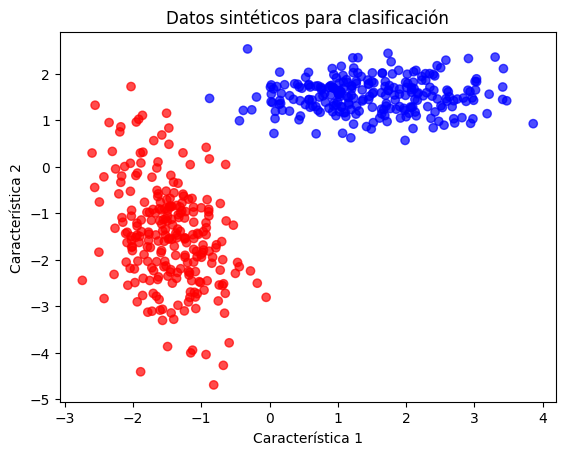

In [ ]:
# Generar dataset sintético
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, n_clusters_per_class=1, flip_y=0, class_sep=1.5, random_state=40)

# Graficar los datos
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)
plt.title('Datos sintéticos para clasificación')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

## 3. Train-Test Split

We split the data into two subsets:

- **Training set (70%)**: used to fit the model.
- **Test set (30%)**: used to evaluate the model's performance on unseen data.

This step is important to prevent overfitting.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Tamaño train: {X_train.shape[0]} samples')
print(f'Tamaño test: {X_test.shape[0]} samples')

Tamaño train: 350 samples
Tamaño test: 150 samples


## 4. Training the Model

We create an instance of the `LogisticRegression` model and train it using the training data (`X_train` and `y_train`).

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## 5. Model Evaluation

After training the model, we use it to make predictions on the test set with `model.predict(X_test)`.

We then evaluate its performance using **accuracy**, which is the proportion of correctly classified samples:

```python
accuracy_score(y_test, y_pred)```

Accuracy en test: 1.00


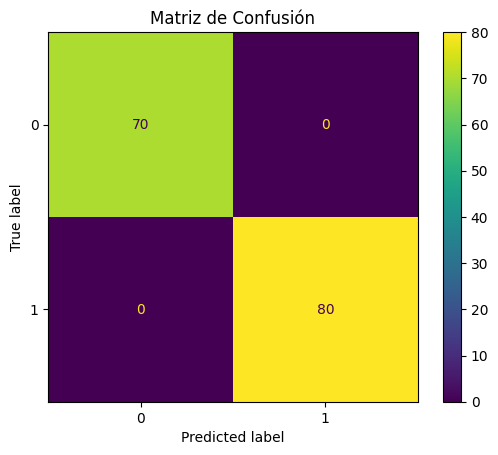

In [ ]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy en test: {acc:.2f}')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Matriz de Confusión')
plt.show()

## 7. Visualizing the Decision Boundary

To better understand how the logistic regression model separates the classes, we plot the **decision boundary**. This boundary shows the regions where the model predicts one class versus the other.

We do this by:

1. Creating a grid (mesh) that covers the entire feature space.
2. Predicting the class for every point in the grid.
3. Using `contourf` to shade the regions according to the predicted class.

We also overlay the original data points on the plot to show how well the model's predictions align with the actual data.

This visualization helps us see whether the model has learned a linear separation between classes, as expected from logistic regression.



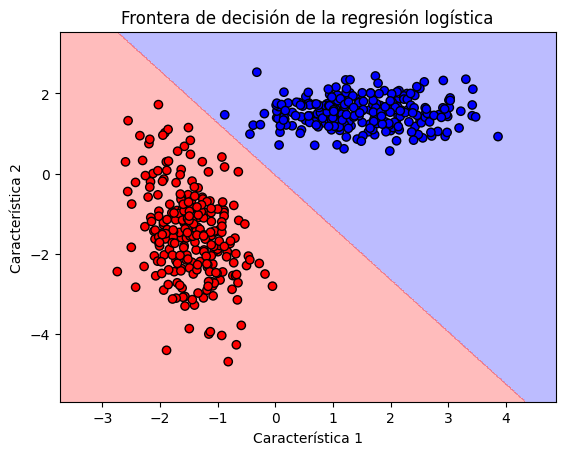

In [ ]:
# Crear malla para graficar frontera
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title('Frontera de decisión de la regresión logística')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()


## 8. Implementing Logistic Regression from Scratch

To deepen our understanding, we now implement logistic regression manually using **NumPy**. This allows us to see how the algorithm works under the hood.

### Steps:

1. **Bias Term**: We add a column of ones to the input matrix to account for the bias term in the model.
2. **Sigmoid Function**: This is the activation function used in logistic regression. It maps any real-valued number into the (0, 1) interval.
3. **Loss Function**: We use binary cross-entropy (log loss) to measure the difference between predicted probabilities and true labels.
4. **Gradient Descent**:
   - We update the weights iteratively.
   - On each iteration, we compute the gradient of the loss with respect to the weights.
   - We adjust the weights in the direction that reduces the loss.
   - Every 100 epochs, we print the current loss to monitor convergence.

This custom implementation helps illustrate how logistic regression learns from the data.

In [ ]:
import numpy as np

# Añadir columna de 1 para bias
X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(X, y, weights):
    m = len(y)
    h = sigmoid(X @ weights)
    epsilon = 1e-5
    loss = -(1/m) * (y @ np.log(h + epsilon) + (1 - y) @ np.log(1 - h + epsilon))
    return loss

def gradient_descent(X, y, weights, lr=0.1, epochs=500):
    m = len(y)
    for i in range(epochs):
        h = sigmoid(X @ weights)
        gradient = (1/m) * X.T @ (h - y)
        weights -= lr * gradient
        if i % 100 == 0:
            print(f"Epoch {i}: loss = {compute_loss(X, y, weights):.4f}")
    return weights

# Inicializamos pesos en cero (bias + características)
weights = np.zeros(X_train_bias.shape[1])

# Entrenamos con gradiente descendente
weights = gradient_descent(X_train_bias, y_train, weights)

print("Pesos finales:", weights)

Epoch 0: loss = 0.5900
Epoch 100: loss = 0.0451
Epoch 200: loss = 0.0274
Epoch 300: loss = 0.0205
Epoch 400: loss = 0.0168
Pesos finales: [ 0.02095623 -2.15328744 -1.83923431]


## 9. Evaluating the Manual Implementation

Now that we've trained our logistic regression model using gradient descent, we evaluate it just like we did with `scikit-learn`'s version.

### Steps:

1. **Add Bias Term to Test Set**: We prepend a column of ones to the test data, matching the format used in training.
2. **Predict Probabilities**: We compute the dot product between the input and the learned weights, then apply the sigmoid function to get probabilities.
3. **Class Prediction**: We convert the probabilities into binary class labels using a threshold of 0.5.
4. **Accuracy & Confusion Matrix**:
   - We calculate the accuracy of the manual model.
   - We display the confusion matrix to visualize its performance.

This allows us to compare the manual implementation's performance to that of the built-in `LogisticRegression` class and confirm that our model works as expected.


Accuracy en test: 1.00


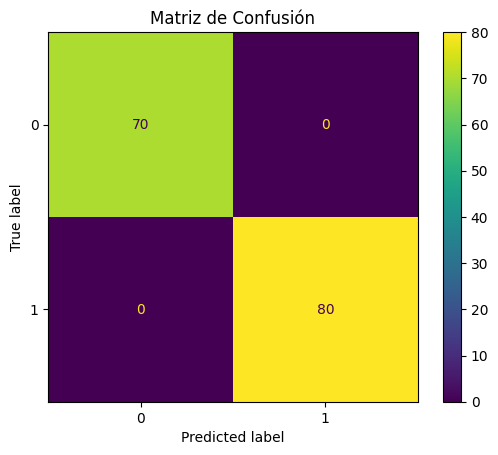

In [ ]:
# Añadir bias a X_test también
X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

# Predicción probabilística
probs = sigmoid(X_test_bias @ weights)

# Convertir probabilidades a etiquetas (umbral 0.5)
y_pred_manual = (probs >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred_manual)
print(f'Accuracy en test: {acc:.2f}')

cm = confusion_matrix(y_test, y_pred_manual)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Matriz de Confusión')
plt.show()

## 10. Visualizing the Manual Decision Boundary

Just like we did with the `scikit-learn` model, we now visualize the **decision boundary** for our custom logistic regression implementation.

### Steps:

1. **Mesh Grid**: We generate a grid of (x, y) points covering the entire input space.
2. **Add Bias**: Since our manual model includes a bias term, we prepend a column of ones to the grid.
3. **Predict Probabilities**: We compute the predicted probabilities using the learned weights and the sigmoid function.
4. **Convert to Labels**: We apply a 0.5 threshold to classify the grid points.
5. **Plot**: We use `contourf` to shade the decision regions and overlay the original data points.

This lets us visually confirm that our manually trained model behaves similarly to the scikit-learn version.


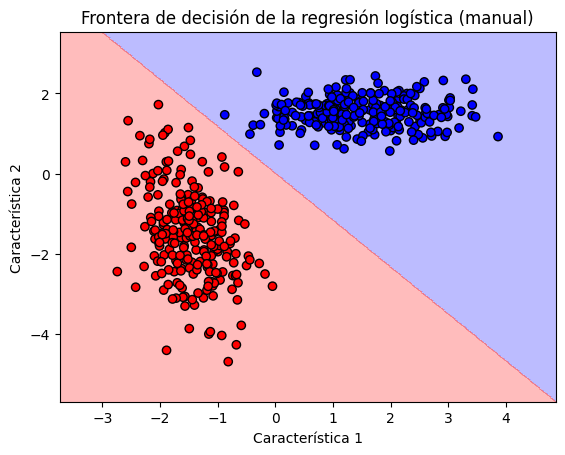

In [ ]:
# Crear malla para graficar frontera
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

# Añadir columna de 1 para bias a la malla
grid = np.c_[np.ones(xx.ravel().shape[0]), xx.ravel(), yy.ravel()]

# Calcular probabilidades con la función sigmoide y pesos manuales
probs = sigmoid(grid @ weights)

# Aplicar umbral para obtener etiquetas predichas
Z = (probs >= 0.5).astype(int)

# Dar forma para graficar
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title('Frontera de decisión de la regresión logística (manual)')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()


## 11. Multiclass Classification: Synthetic Dataset

In this section, you will generate a synthetic dataset with **three distinct classes**. You will use `make_classification` to create the data and `matplotlib` to visualize it.

👉 **Task**:
- Generate a dataset with 500 samples, 2 features, and 3 classes.
- Plot the data points with colors representing the class labels.


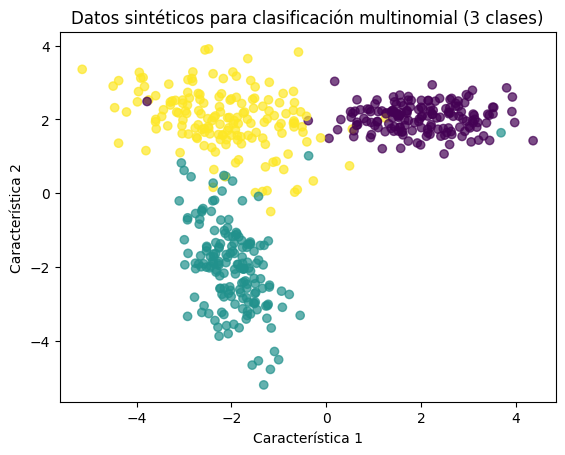

In [ ]:
# TODO: Generate a synthetic dataset with 3 classes
# Hint: use n_samples=500, n_features=2, n_redundant=0, n_clusters_per_class=1, n_classes=3, class_sep=2, random_state=40,

# X, y = ...

# TODO: Plot the dataset using scatter plot
# plt.scatter(..., c=y, cmap='viridis', alpha=0.7)
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# plt.show()

## 12. Training a Multinomial Logistic Regression Model

Now you'll train a **logistic regression model** to handle the three-class classification task using scikit-learn.

👉 **Task**:
- Split the dataset into a training set and a test set (70/30).
- Create and train a logistic regression model using `multi_class='multinomial'` and `solver='lbfgs'`.


In [ ]:
# TODO: Split the data into training and test sets
# X_train, X_test, y_train, y_test = ...

# TODO: Create a multinomial logistic regression model
# model = LogisticRegression(...)

# TODO: Train the model
# model.fit(...)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=500, multi_class='multinomial')

## 13. Evaluating the Multiclass Model

Evaluate the trained model by measuring its accuracy and displaying the **confusion matrix**.

👉 **Task**:
- Predict class labels for the test set.
- Calculate the accuracy.
- Display the confusion matrix using `ConfusionMatrixDisplay`.


Accuracy en test: 0.96


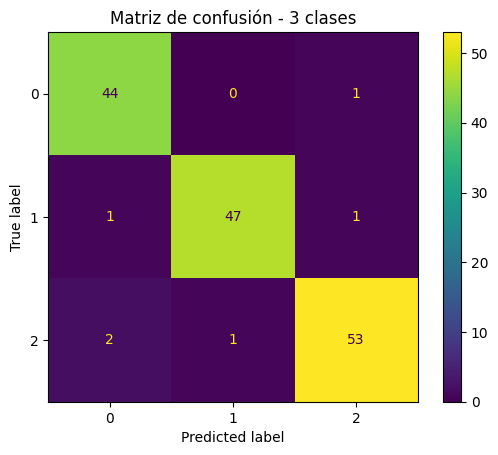

In [ ]:
# TODO: Predict class labels on the test set
# y_pred = ...

# TODO: Compute and print accuracy
# acc = ...
# print(f'Accuracy: {acc:.2f}')

# TODO: Display confusion matrix
# cm = ...
# disp = ConfusionMatrixDisplay(...)
# disp.plot()
# plt.title(...)
# plt.show()

## 14. Visualizing the Decision Boundaries (3 Classes)

Finally, visualize the **decision regions** created by your multinomial logistic regression model.

👉 **Task**:
- Generate a mesh grid across the feature space.
- Predict class labels for each point in the grid.
- Plot the decision boundaries using `contourf`, and overlay the original data points.


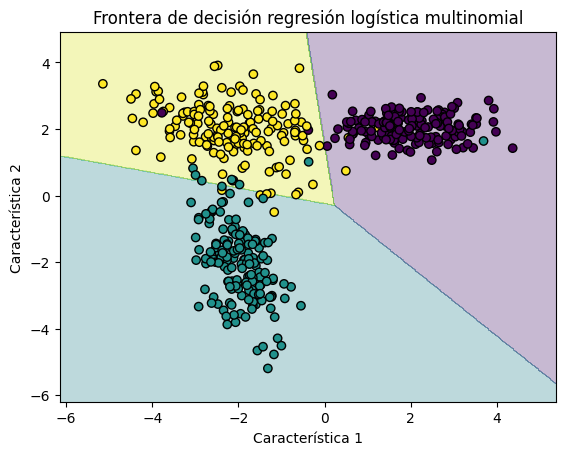

In [ ]:
# TODO: Create a mesh grid
# x_min, x_max = ...
# y_min, y_max = ...
# xx, yy = ...
# mesh_points = np.c_[xx.ravel(), yy.ravel()]

# TODO: Predict labels for each point in the mesh
# Z = ...

# TODO: Reshape and plot decision boundaries
# Z = ...
# plt.contourf(...)
# plt.scatter(...)
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# plt.show()